**Data Science, Data Analytics**

Data analysis, visualization, and transformation

* Feature Engineering acts as a data architector: "How do I build the model's foundation?"
* Goal: To Transfom raw data into meaningful features that improve model performance.
* Focus: Creation, transformation, selection, and encoding of features. It is about rewriting that story in a way that machine learning models can understand.
* Common tasks: Scaling, one-hot encoding, binning, and creating interaction terms.
* It takes the insights from EDA and applies them to prepare data for modeling.

#### Author: Victor Villa

---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Let's use `fitness.csv` which has information about people who bougth a treadmill at a retail store during three months.
* `Product`: treadmill models (TM195, TM498, TM798)
* `Age`: age in years
* `Gender`: Male or Female
* `Education`: level education in years
* `MaritalStatus`: Single or Partnered
* `Usage`: How often the user will use the treadmill per week
* `Fitness`: Self-assessed fitness on a scale of 1 to 5, where 1 is poor shape and 5 is excellent shape.
* `Income`: Anual income in us dollars.
* `Miles`: Mile average that user expects to walk/run each week.

Reference: https://www.kaggle.com/datasets/saurav9786/cardiogoodfitness

In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/AI-LearningPath/fitness.csv')
df

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,TM195,18,Male,14,Single,3,4,29562,112
1,TM195,19,Male,15,Single,2,3,31836,75
2,TM195,19,Female,14,Partnered,4,3,30699,66
3,TM195,19,Male,12,Single,3,3,32973,85
4,TM195,20,Male,13,Partnered,4,2,35247,47
...,...,...,...,...,...,...,...,...,...
175,TM798,40,Male,21,Single,6,5,83416,200
176,TM798,42,Male,18,Single,5,4,89641,200
177,TM798,45,Male,16,Single,5,5,90886,160
178,TM798,47,Male,18,Partnered,4,5,104581,120


In [3]:
# Visualization libs
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [5]:
# Number of unique values per column
df.nunique()

,0
Product,3
Age,32
Gender,2
Education,8
MaritalStatus,2
Usage,6
Fitness,5
Income,62
Miles,37


In [6]:
# Descriptive statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,180.0,28.788889,6.943498,18.0,24.00,26.0,33.00,50.0
Education,180.0,15.572222,1.617055,12.0,14.00,16.0,16.00,21.0
Usage,180.0,3.455556,1.084797,2.0,3.00,3.0,4.00,7.0
Fitness,180.0,3.311111,0.958869,1.0,3.00,3.0,4.00,5.0
Income,180.0,53719.577778,16506.684226,29562.0,44058.75,50596.5,58668.00,104581.0
Miles,180.0,103.194444,51.863605,21.0,66.00,94.0,114.75,360.0


In [7]:
# Descriptive statistics for object/text variables
df.describe(include = 'object').T

,count,unique,top,freq
Product,180,3,TM195,80
Gender,180,2,Male,104
MaritalStatus,180,2,Partnered,107


In [8]:
# Let's make two lists, one for numerical variables and other for categorical variables.
num_cols = ['Age', 'Education', 'Usage', 'Income', 'Miles']
cat_cols = ['Product', 'Gender', 'MaritalStatus', 'Fitness']

In [9]:
# Count values by unique category for each categoric variables
for column in cat_cols:
    print(column)
    print(df[column].value_counts())
    print('-' * 50)

Product
Product
TM195    80
TM498    60
TM798    40
Name: count, dtype: int64
--------------------------------------------------
Gender
Gender
Male      104
Female     76
Name: count, dtype: int64
--------------------------------------------------
MaritalStatus
MaritalStatus
Partnered    107
Single        73
Name: count, dtype: int64
--------------------------------------------------
Fitness
Fitness
3    97
5    31
2    26
4    24
1     2
Name: count, dtype: int64
--------------------------------------------------


In [10]:
# Check missing values
df.isna().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


## **Univariate Analysis**

Numerical variables

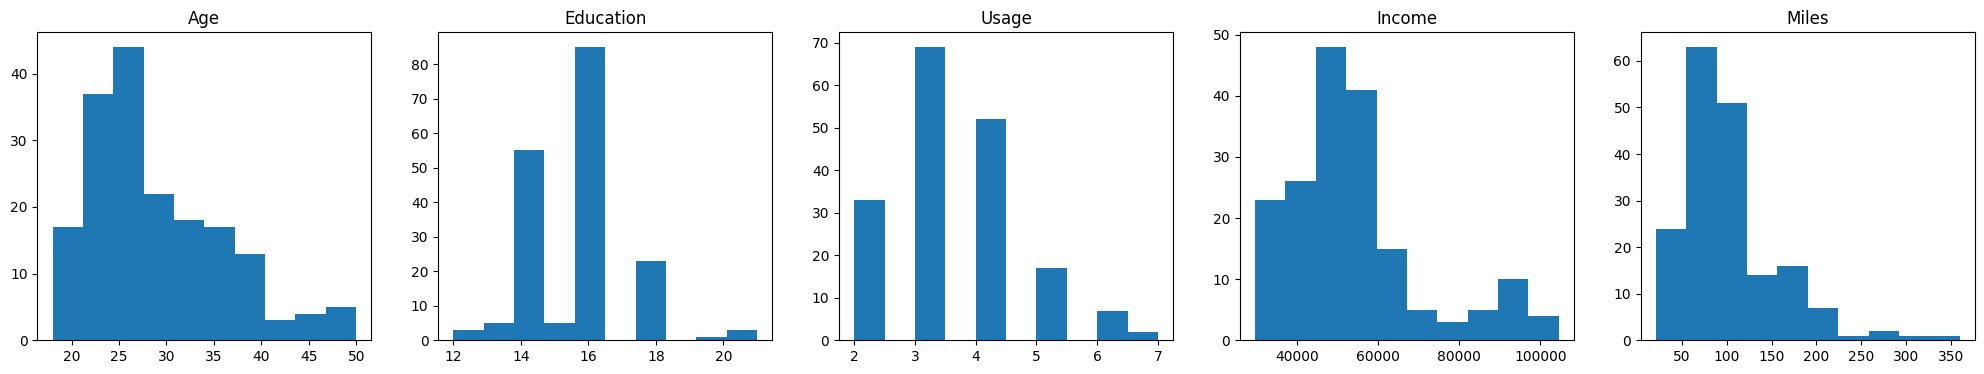

In [11]:
fig, axes = plt.subplots(1,5, figsize=(25,4))
axes = axes.ravel()
for col, ax in zip(df[num_cols], axes):
  ax.hist(df[col])
  ax.set(title=f'{col}', xlabel=None)

/tmp/ipykernel_3934/1238924392.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(df[col], labels=[f'{col}'])
/tmp/ipykernel_3934/1238924392.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(df[col], labels=[f'{col}'])
/tmp/ipykernel_3934/1238924392.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(df[col], labels=[f'{col}'])
/tmp/ipykernel_3934/1238924392.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(df[col], labels=[f'{col}'])
/tmp/ipykern

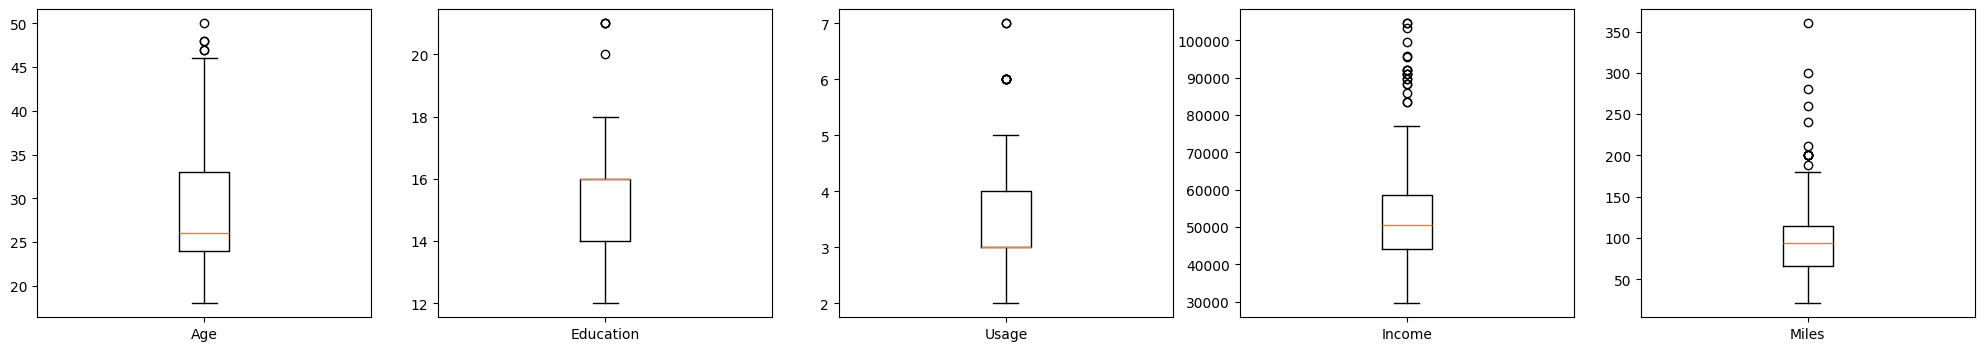

In [12]:
fig, axes = plt.subplots(1,5, figsize=(25,4))
axes = axes.ravel()
for col, ax in zip(df[num_cols], axes):
  ax.boxplot(df[col], labels=[f'{col}'])

Categorical variables

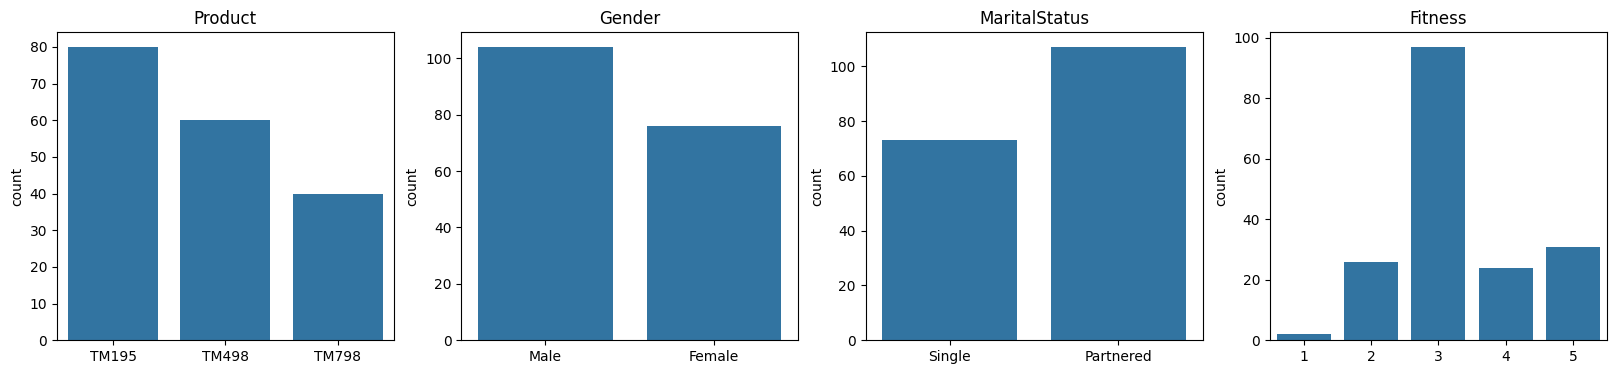

In [13]:
fig, axes = plt.subplots(1,4, figsize=(20,4))
axes = axes.ravel()
for col, ax in zip(df[cat_cols], axes):
  sns.countplot(x=df[col], ax=ax)
  ax.set(title=f'{col}', xlabel=None)

## **Bivariate Analysis**

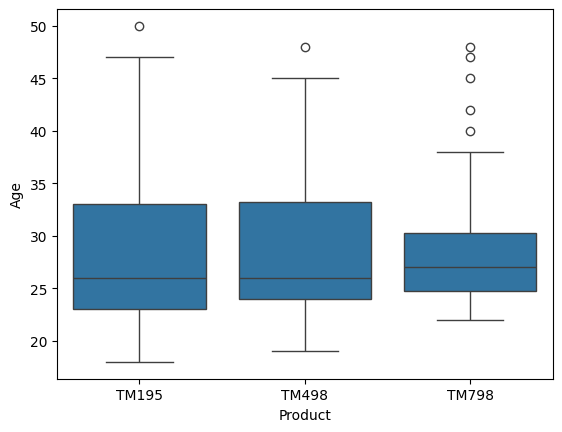

In [14]:
# To determine if age influences the product purchased.
sns.boxplot(x='Product', y='Age', data=df)
plt.show()

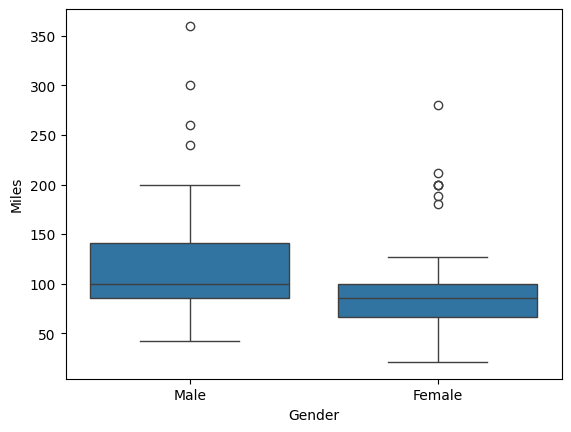

In [15]:
# To determine wether gender influences the number of miles
sns.boxplot(x='Gender', y='Miles', data=df)
plt.show()

## **Multivariate Analysis**

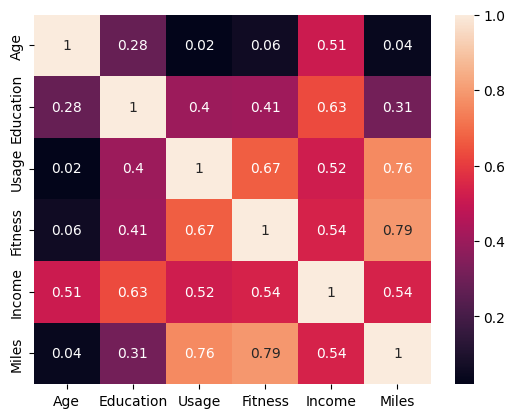

In [16]:
sns.heatmap(round(df.corr(numeric_only=True),2), annot = True)
plt.show()

## **Feature Engineering**

In [17]:
# Age Discretization (binning)

from sklearn.preprocessing import KBinsDiscretizer

grouper = KBinsDiscretizer(n_bins=3, strategy='uniform', encode='onehot-dense')
grouped = grouper.fit_transform(df[['Age']])
grouped_df = pd.DataFrame(grouped, columns=grouper.get_feature_names_out())
grouped_df

,Age_0.0,Age_1.0,Age_2.0
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0
...,...,...,...
175,0.0,0.0,1.0
176,0.0,0.0,1.0
177,0.0,0.0,1.0
178,0.0,0.0,1.0


In [18]:
# Encoding object/text categorical variables (one hot encoder)

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(df[['Product', 'Gender', 'MaritalStatus']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out())
encoded_df

,Product_TM498,Product_TM798,Gender_Male,MaritalStatus_Single
0,0.0,0.0,1.0,1.0
1,0.0,0.0,1.0,1.0
2,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,1.0
4,0.0,0.0,1.0,0.0
...,...,...,...,...
175,0.0,1.0,1.0,1.0
176,0.0,1.0,1.0,1.0
177,0.0,1.0,1.0,1.0
178,0.0,1.0,1.0,0.0


In [19]:
# Transform skewed numerical variables (Gaussian-like distribution via Yeo-Johnson or Box-Cox)

from sklearn.preprocessing import PowerTransformer

transformer = PowerTransformer(method='box-cox', standardize=False)
transf = transformer.fit_transform(df[['Income','Miles']])
transf_df = pd.DataFrame(transf, columns=transformer.get_feature_names_out())
transf_df

,Income,Miles
0,1.365525,3.798889
1,1.365564,3.538352
2,1.365545,3.453180
3,1.365581,3.620744
4,1.365613,3.221864
...,...,...
175,1.365913,4.158393
176,1.365931,4.158393
177,1.365934,4.022388
178,1.365965,3.842717


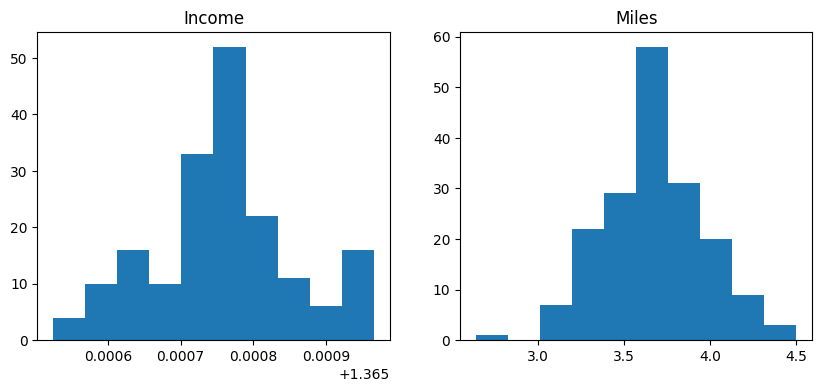

In [20]:
# Plotting transformation of skewed numerical variables.

fig, axes = plt.subplots(1,2, figsize=(10,4))
axes = axes.ravel()
for col, ax in zip(transf_df, axes):
  ax.hist(transf_df[col])
  ax.set(title=f'{col}', xlabel=None)

In [21]:
# Scale skewed numerical variables (MinMax)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
minmax = scaler.fit_transform(transf_df)
minmax_df = pd.DataFrame(minmax, columns=scaler.get_feature_names_out())
minmax_df

,Income,Miles
0,0.000000,0.621619
1,0.087502,0.481626
2,0.045154,0.435861
3,0.127309,0.525897
4,0.200201,0.311569
...,...,...
175,0.881687,0.814790
176,0.921490,0.814790
177,0.928881,0.741711
178,1.000000,0.645169


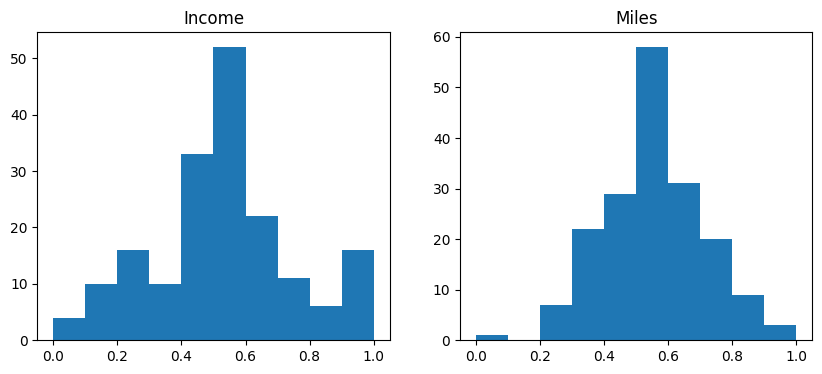

In [22]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
axes = axes.ravel()
for col, ax in zip(minmax_df, axes):
  ax.hist(minmax_df[col])
  ax.set(title=f'{col}', xlabel=None)